# 《生物医学图像处理》实验3 实验报告

实验名称：Spatial Filter and Fourier Transform

姓名：林亨  学号：3230103696  专业：生物医学工程

**声明：本实验所有代码在gemini 3 pro辅助下完成，本人已充分理解代码内容**

## Project1：Ringing Effect

### 实验内容

- 编写代码实现低通滤波器 ($D_0=30$) 

   - 理想低通 (Ideal Low-pass) 

   - 阶数为 n=6 的巴特沃斯 (Butterworth) 滤波器 

   - 高斯 (Gaussian) 滤波器 

- 指出振铃效应并解释其产生的原因

### 实验原理

在频率域中，图像的低频分量代表了图像平缓的背景和整体的灰度分布，而高频分量代表了图像的边缘、细节和噪声。低通滤波器的作用就是让低频信号通过，截断或衰减高频信号，从而达到平滑（模糊）图像的目的。

本实验比较了三种经典的低通滤波器。

#### 理想低通滤波器 (Ideal Low-pass Filter, ILPF)

理想低通滤波器具有一个极其尖锐的截断频率 $D_0$。在这个频率以内的信号完全通过，以外的信号完全被阻挡。其传递函数为：$$H(u,v) = \begin{cases} 1, & \text{if } D(u,v) \le D_0 \\ 0, & \text{if } D(u,v) > D_0 \end{cases}$$

其中 $D(u,v)$ 是频率域中点 $(u,v)$ 到中心的距离。

#### 巴特沃斯低通滤波器 (Butterworth Low-pass Filter, BLPF)

巴特沃斯滤波器在通带和阻带之间有一个平滑的过渡，过渡的陡峭程度由阶数 $n$ 决定。阶数越高，过渡越陡峭，越接近理想低通滤波器。其传递函数为：$$H(u,v) = \frac{1}{1 + (D(u,v)/D_0)^{2n}}$$

#### 高斯低通滤波器 (Gaussian Low-pass Filter, GLPF)
  
高斯滤波器的传递函数是一个平滑的高斯钟形曲线。它没有尖锐的截断，高频分量是逐渐衰减的。其传递函数为：$$H(u,v) = e^{-D^2(u,v)/(2D_0^2)}$$

### 实验过程（代码编写）


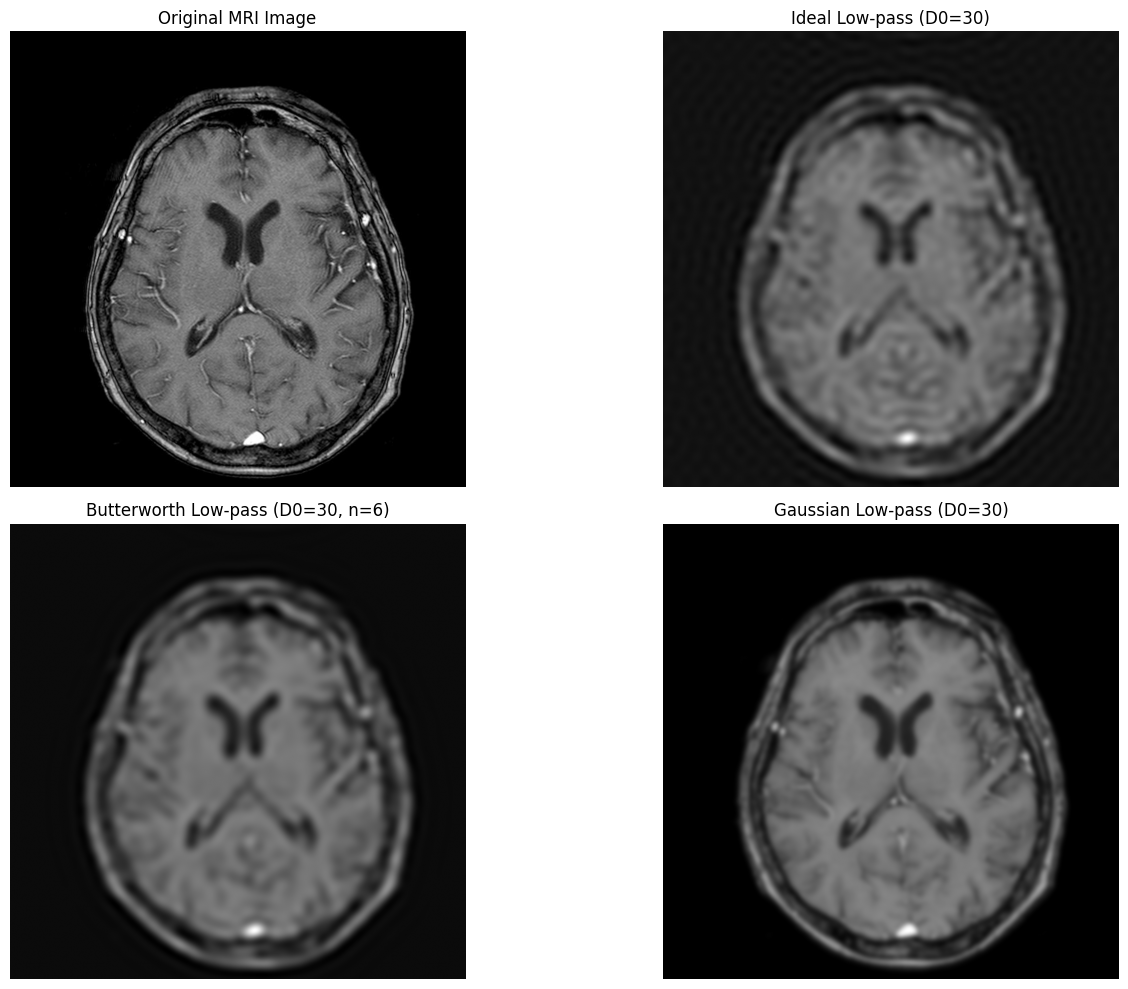

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def create_filters(shape, D0, n=6):
    """
    使用矩阵运算生成三种低通滤波器：理想、巴特沃斯、高斯。
    """
    P, Q = shape
    # 生成网格坐标 (对应于频率域的 u 和 v)
    u = np.arange(P)
    v = np.arange(Q)
    
    # 将原点平移到中心点
    u = u - P / 2
    v = v - Q / 2
    
    # 使用 meshgrid 生成二维矩阵，避免使用 for 循环 (使用矩阵算子)
    U, V = np.meshgrid(v, u)
    
    # 计算频率域中每个点到中心 (零频率点) 的距离 D(u, v)
    D = np.sqrt(U**2 + V**2)
    
    # 1. 理想低通滤波器 (Ideal Low-pass)
    # 距离小于等于 D0 的部分设为 1，其余设为 0
    H_ideal = np.zeros_like(D)
    H_ideal[D <= D0] = 1
    
    # 2. 巴特沃斯低通滤波器 (Butterworth Low-pass), 阶数 n=6
    # 按照公式：1 / (1 + (D / D0)^(2n))
    # 加上一个极小值 eps 防止 D0=0 时报错，虽然这里 D0=30 不会为 0
    H_butter = 1 / (1 + (D / D0)**(2 * n))
    
    # 3. 高斯低通滤波器 (Gaussian Low-pass)
    # 按照公式：e^(-D^2 / (2 * D0^2))
    H_gaussian = np.exp(-(D**2) / (2 * D0**2))
    
    return H_ideal, H_butter, H_gaussian

def apply_filter(F_shifted, H):
    """
    在频率域应用滤波器，并返回空间域的图像。
    """
    # 1. 在频率域将频谱与滤波器相乘
    G_shifted = F_shifted * H
    
    # 2. 逆中心化 (将低频移回左上角)
    G = np.fft.ifftshift(G_shifted)
    
    # 3. 进行二维傅里叶逆变换回到空间域
    img_filtered = np.fft.ifft2(G)
    
    # 4. 取实部作为最终图像 (忽略因为计算误差产生的极小虚部)
    return np.real(img_filtered)

# ================= 主程序 =================

# 1. 加载 MRI 数据
# 假设 lab3.npy 是一个 2D 数组 (灰度图像)
img = np.load('lab3.npy')

# 2. 二维快速傅里叶变换 (FFT)
F = np.fft.fft2(img)

# 3. 将零频率分量(低频)移到频谱中心
F_shifted = np.fft.fftshift(F)

# 4. 设定参数：截断频率 D0 = 30, 巴特沃斯阶数 n = 6
D0 = 30
n = 6

# 5. 生成三种滤波器
H_ideal, H_butter, H_gaussian = create_filters(img.shape, D0, n)

# 6. 分别应用滤波器获取处理后的图像
img_ideal = apply_filter(F_shifted, H_ideal)
img_butter = apply_filter(F_shifted, H_butter)
img_gaussian = apply_filter(F_shifted, H_gaussian)

# 7. 可视化结果
plt.figure(figsize=(15, 10))

# 原始图像
plt.subplot(2, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original MRI Image')
plt.axis('off')

# 理想低通滤波结果
plt.subplot(2, 2, 2)
plt.imshow(img_ideal, cmap='gray')
plt.title(f'Ideal Low-pass (D0={D0})')
plt.axis('off')

# 巴特沃斯低通滤波结果
plt.subplot(2, 2, 3)
plt.imshow(img_butter, cmap='gray')
plt.title(f'Butterworth Low-pass (D0={D0}, n={n})')
plt.axis('off')

# 高斯低通滤波结果
plt.subplot(2, 2, 4)
plt.imshow(img_gaussian, cmap='gray')
plt.title(f'Gaussian Low-pass (D0={D0})')
plt.axis('off')

plt.tight_layout()
plt.show()

### 实验结果与分析

通过对比三种滤波器的输出图像，我们可以观察到以下现象。

#### 滤波效果差异

三种滤波器都能有效去除图像的高频细节，使大脑 MRI 图像变得平滑模糊。但在相同截断频率 $D_0$ 下，高斯滤波器的过渡最为平缓，视觉上最为柔和；理想低通滤波器的平滑效果最生硬；而 $n=6$ 的巴特沃斯滤波器效果介于两者之间。

#### 振铃效应 (Ringing Effect) 的产生与原因

在理想低通滤波器的结果中，可以明显观察到图像边缘（如大脑轮廓、内部高对比度结构）周围出现了类似水波纹的同心明暗光环，这就是振铃效应。阶数为 6 的巴特沃斯滤波器也有轻微的振铃效应，而高斯滤波器则几乎没有产生振铃现象。

这是因为频率域中的乘法等效于空间域中的卷积。理想低通滤波器在频率域的截断是一个矩形函数，其傅里叶逆变换到空间域是一个sinc函数 (即 $\frac{\sin(x)}{x}$)。sinc函数具有一个中心主瓣和两侧逐渐衰减的交替正负旁瓣。当这个带有旁瓣的函数与原图像在空间域进行卷积时，旁瓣会在图像边缘引起灰度值的震荡，从而在视觉上形成了波纹。高斯函数的傅里叶逆变换依然是平滑的高斯函数，没有旁瓣，因此不会产生振铃效应。

## Project 2: Identical filter

### 实验内容

- 实现空间滤波器 

  - 低通高斯滤波器 ($\sigma$ 的值可以取 1, 3, 5) 

  - 对应的高通高斯滤波器 

- 应用频率滤波器 

  - 基于空间核快速傅里叶变换 (Spatial Kernel FFT) 的滤波器 

- 实现拉普拉斯 (Laplacian) 高通滤波器 

  - 具有 4 邻域和 8 邻域的 3*3 滤波器 

- 分析并讨论以下各项之间的差异： 

  - 频率滤波器和空间滤波器 

  - 高斯高通滤波器和拉普拉斯滤波器

### 实验原理

#### 空间滤波器
直接在图像的像素空间进行操作，通常通过一个固定大小的卷积核（掩膜）在图像上滑动计算局部邻域的加权和。

#### 低通高斯滤波器
卷积核的权重呈高斯分布，中心权重最大，向四周平滑递减，用于空间域平滑。

#### 高斯高通滤波器
可通过原图减去低通高斯滤波的结果获得，用于保留高频边缘。

#### 频率滤波器
利用快速傅里叶变换 (FFT) 将图像转换到频率域，与滤波器的传递函数直接相乘，再通过逆傅里叶变换 (IFFT) 转回空间域。

#### 拉普拉斯高通滤波器
一种基于空间域二阶导数的各向同性边缘检测算子。它对图像中的灰度阶跃（强边缘）极其敏感。实验中使用了 4 邻域和 8 邻域的 $3 \times 3$ 卷积核。

### 实验过程（代码编写）

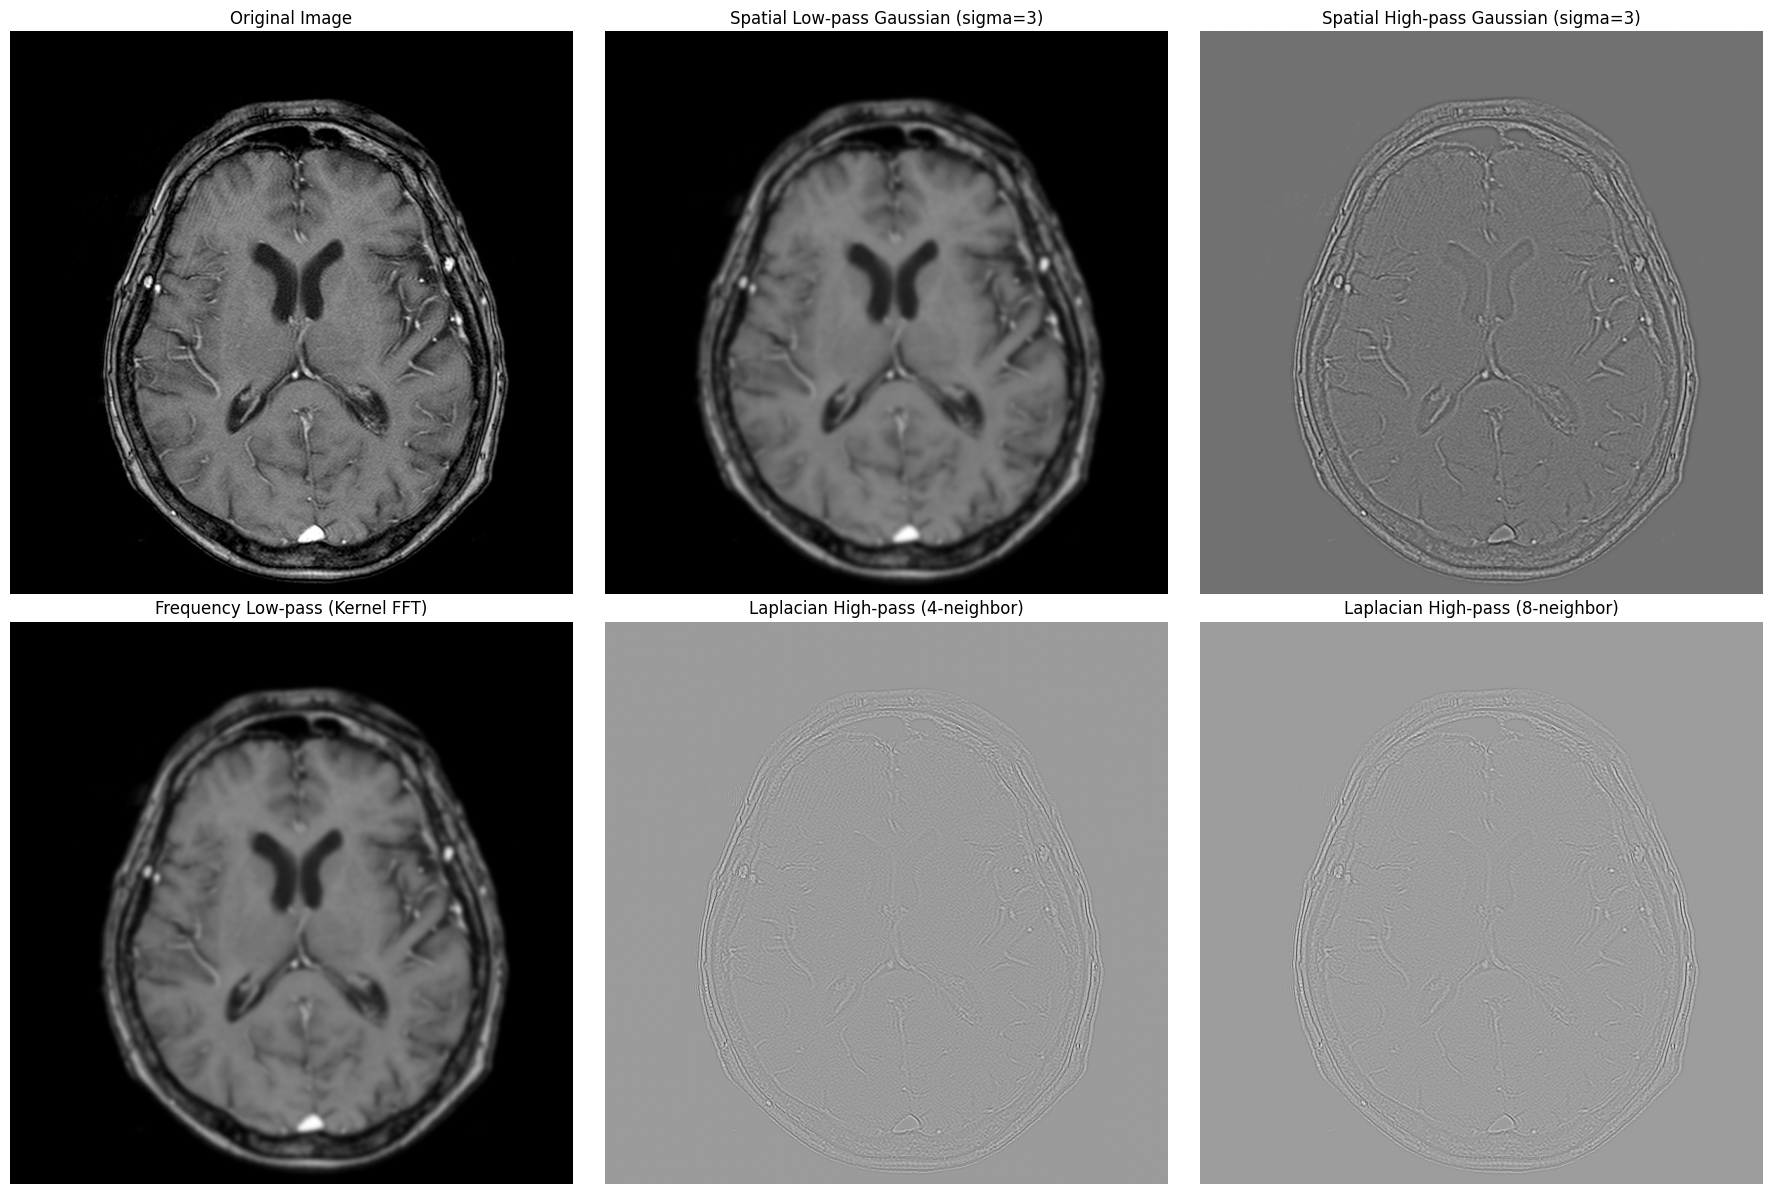

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# ================= 辅助函数 =================

def get_gaussian_kernel(sigma):
    """
    生成一个二维空间高斯低通滤波器核 (Spatial Low-pass Gaussian Kernel)
    大小取决于 sigma，通常取 6*sigma + 1 以保证截断误差极小。
    """
    size = int(2 * np.ceil(3 * sigma) + 1)
    # 生成网格坐标，中心点为 (0,0)
    x, y = np.mgrid[-size//2 + 1:size//2 + 1, -size//2 + 1:size//2 + 1]
    
    # 高斯函数公式: (1/(2*pi*sigma^2)) * exp(-(x^2+y^2)/(2*sigma^2))
    g = np.exp(-((x**2 + y**2) / (2.0 * sigma**2)))
    
    # 归一化，使得所有权重之和为1，保证滤波后图像整体亮度不变
    return g / g.sum()

def apply_freq_filter_from_spatial_kernel(img, kernel):
    """
    将空间核转换到频率域，并在频率域进行滤波 (Filter based on Spatial Kernel FFT)
    """
    # 1. 零填充：创建一个与原图同样大小的全零矩阵，并将空间核放入其中
    padded_kernel = np.zeros_like(img, dtype=np.float64)
    kh, kw = kernel.shape
    padded_kernel[:kh, :kw] = kernel
    
    # 2. 循环位移：将核的中心移动到矩阵的左上角 (0,0) 处
    # 这一步是为了防止频率域滤波后产生空间平移 (Phase shift)
    padded_kernel = np.roll(padded_kernel, -kh//2, axis=0)
    padded_kernel = np.roll(padded_kernel, -kw//2, axis=1)
    
    # 3. 对图像和填充后的核分别进行二维傅里叶变换
    F_img = np.fft.fft2(img)
    F_kernel = np.fft.fft2(padded_kernel) # 这就是等效的频率域滤波器 H(u,v)
    
    # 4. 在频率域将二者相乘 (对应于空间域的卷积)
    F_filtered = F_img * F_kernel
    
    # 5. 傅里叶逆变换回到空间域，并取实部
    img_filtered = np.real(np.fft.ifft2(F_filtered))
    return img_filtered

# ================= 主程序 =================

# 1. 加载 MRI 数据
img = np.load('lab3.npy').astype(np.float64)

# ================= Part 1: 空间滤波器 (Spatial Filters) =================
# 1.1 低通高斯滤波器 (Low pass Gaussian)
sigma = 3 # 按照要求，sigma 可以取 1, 3, 5。这里以 3 为例
gaussian_kernel_lp = get_gaussian_kernel(sigma)

# 在空间域使用卷积函数应用低通滤波器 (边界处理采用 'symm' 对称填充)
img_gaussian_lp_spatial = convolve2d(img, gaussian_kernel_lp, mode='same', boundary='symm')

# 1.2 对应的高通高斯滤波器 (High pass Gaussian)
# 高通 = 原图 - 低通
img_gaussian_hp_spatial = img - img_gaussian_lp_spatial


# ================= Part 2: 频率滤波器 (Frequency Filters) =================
# 2.1 基于空间核的快速傅里叶变换滤波器
# 我们使用相同的低通高斯核，但是通过频率域(FFT)来实现滤波
img_gaussian_lp_freq = apply_freq_filter_from_spatial_kernel(img, gaussian_kernel_lp)


# ================= Part 3: 拉普拉斯高通滤波器 (Laplacian High-pass) =================
# 3.1 定义 3x3 4-邻域拉普拉斯核 (中心点权重为 4，上下左右为 -1)
laplacian_kernel_4 = np.array([[ 0, -1,  0],
                               [-1,  4, -1],
                               [ 0, -1,  0]])

# 3.2 定义 3x3 8-邻域拉普拉斯核 (中心点权重为 8，周围8个方向为 -1)
laplacian_kernel_8 = np.array([[-1, -1, -1],
                               [-1,  8, -1],
                               [-1, -1, -1]])

# 在空间域应用拉普拉斯滤波器提取边缘 (高频信息)
img_laplacian_4 = convolve2d(img, laplacian_kernel_4, mode='same', boundary='symm')
img_laplacian_8 = convolve2d(img, laplacian_kernel_8, mode='same', boundary='symm')


# ================= 结果可视化 =================
plt.figure(figsize=(18, 12))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(img_gaussian_lp_spatial, cmap='gray')
plt.title(f'Spatial Low-pass Gaussian (sigma={sigma})')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(img_gaussian_hp_spatial, cmap='gray')
plt.title(f'Spatial High-pass Gaussian (sigma={sigma})')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(img_gaussian_lp_freq, cmap='gray')
plt.title('Frequency Low-pass (Kernel FFT)')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(img_laplacian_4, cmap='gray')
plt.title('Laplacian High-pass (4-neighbor)')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(img_laplacian_8, cmap='gray')
plt.title('Laplacian High-pass (8-neighbor)')
plt.axis('off')

plt.tight_layout()
plt.show()

### 实验结果与分析

#### 频率滤波器与空间滤波器
- 滤波效果等效性：根据卷积定理，空间域的卷积操作在数学上完全等价于频率域的乘法操作。对比实验结果可以发现，使用空间核进行直接卷积，与将空间核进行 FFT 后在频率域滤波的结果几乎完全一致（仅存在极小的浮点计算误差）。
- 计算差异： 对于极小的卷积核（如 $3 \times 3$），空间滤波计算更快；但对于大尺度核（例如 $\sigma$ 较大的高斯核），由于 FFT 具有 $O(N \log N)$ 的时间复杂度，在频率域操作反而具有极大的效率优势。此外，两者的边界处理逻辑不同（空间域通常采用补零或对称镜像，频率域隐含周期性假设），这也是产生微小差异的原因之一。

#### 高斯高通滤波器与拉普拉斯滤波器
- 高斯高通滤波器：由于高斯函数的平滑特性，其提取的边缘相对柔和，不仅突出了强边界，还保留了一部分低频到高频过渡的区域对比度，视觉上更为自然。
- 拉普拉斯滤波器： 作为二阶微分算子，它对高频变化更加敏感，提取出的边缘非常锐利且细致。但是，二阶导数的致命弱点是对噪声极其敏感。如果 MRI 图像中存在细微的背景噪声，拉普拉斯滤波器（尤其是 8 邻域版本）会将其急剧放大，导致结果图像显得非常粗糙和杂乱。

## Project 3：Notch filter

### 实验内容

编写代码实现陷波滤波器以消除噪声。

### 实验原理

陷波滤波器 (Notch Filter) 是一种特殊的带阻滤波器，它的作用是阻止某些特定频率（及其对称频率）通过，而让其他所有频率畅通无阻。它特别适用于消除图像中规则的、周期性的噪声（如本实验中的条纹噪声）。周期性噪声在频率域的幅度谱中通常表现为以原点为对称的、孤立的明亮尖峰。本实验使用巴特沃斯陷波滤波器，在消除目标频率的同时利用其平滑过渡的特性来避免引入振铃效应。

### 实验过程（代码编写）

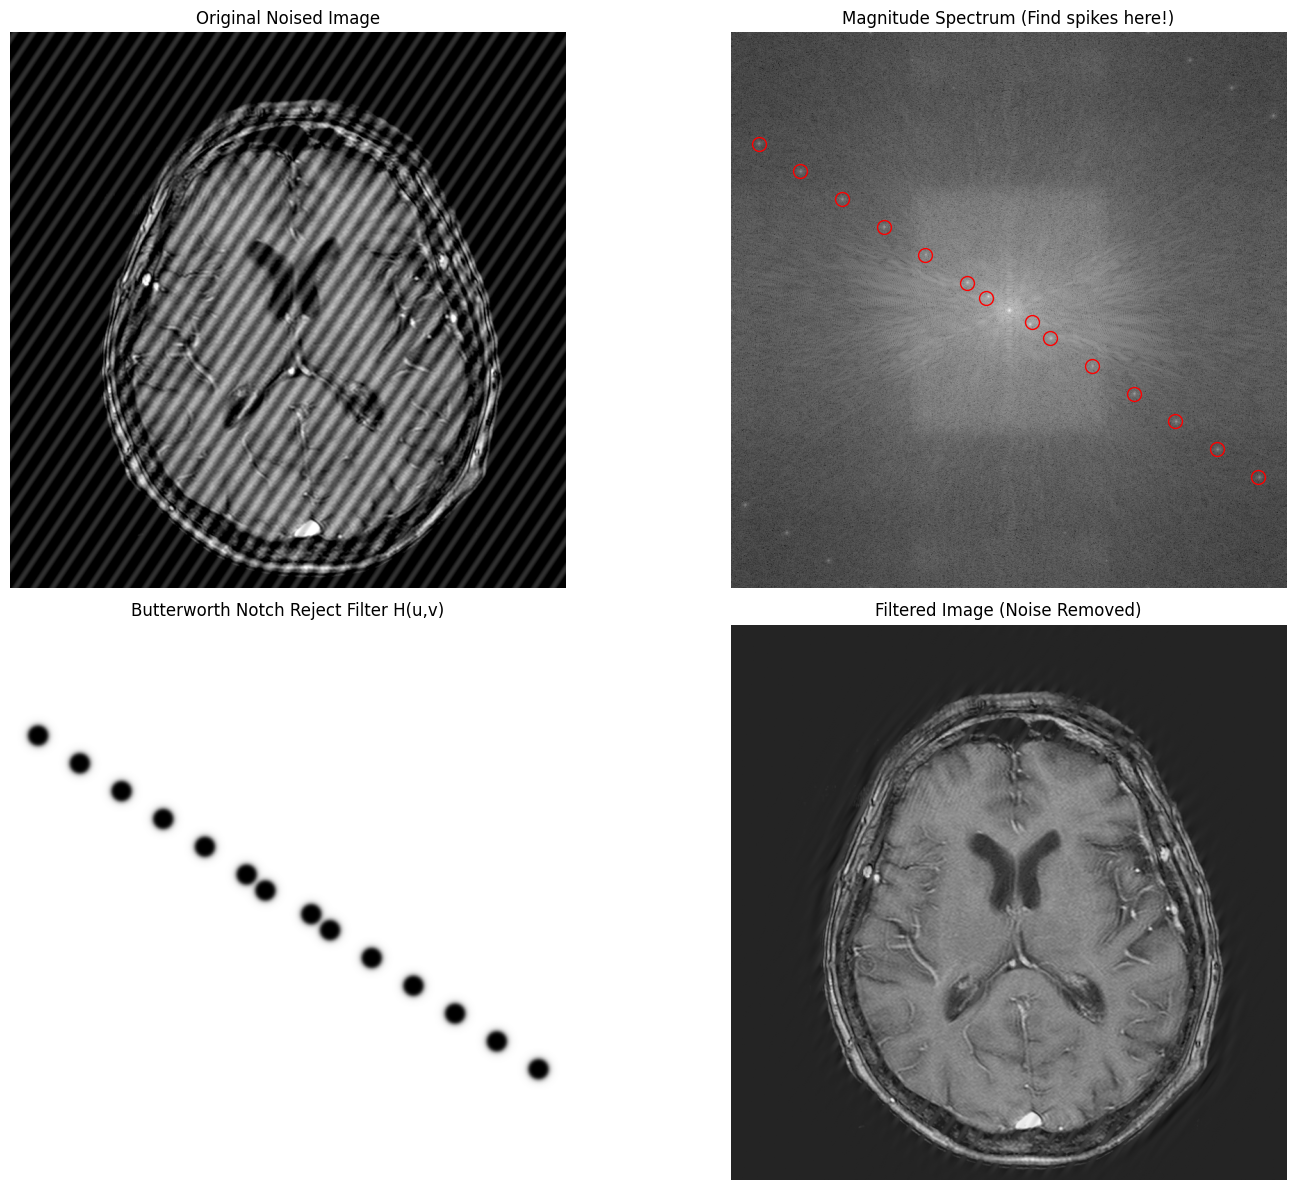

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def create_butterworth_notch(shape, noise_centers, D0=10, n=4):
    """
    生成巴特沃斯陷波带阻滤波器
    :param shape: 图像的形状 (P, Q)
    :param noise_centers: 噪声点的中心坐标列表，格式为 [(u1, v1), (u2, v2)...]
                          注意：坐标是相对于频谱中心 (P/2, Q/2) 的偏移量。
                          输入一个点，代码会自动处理其对称点 (-u, -v)。
    :param D0: 陷波器的半径（抑制范围的宽度）
    :param n: 巴特沃斯滤波器的阶数
    """
    P, Q = shape
    # 生成网格坐标并移至中心
    u = np.arange(P) - P / 2
    v = np.arange(Q) - Q / 2
    V, U = np.meshgrid(v, u)  # U 对应行(y)，V 对应列(x)
    
    # 初始化滤波器为全 1 (全通)
    H = np.ones((P, Q))
    
    # 遍历每个指定的噪声中心
    for (uk, vk) in noise_centers:
        # 计算每个点到噪声中心 (uk, vk) 的距离
        Dk = np.sqrt((U - uk)**2 + (V - vk)**2)
        # 计算每个点到对称噪声中心 (-uk, -vk) 的距离
        Dmk = np.sqrt((U + uk)**2 + (V + vk)**2)
        
        # 加上极小值 1e-5 防止除以 0
        Dk = np.where(Dk == 0, 1e-5, Dk)
        Dmk = np.where(Dmk == 0, 1e-5, Dmk)
        
        # 应用巴特沃斯带阻公式，并乘入总滤波器中
        H_k = (1 / (1 + (D0 / Dk)**(2 * n))) * (1 / (1 + (D0 / Dmk)**(2 * n)))
        H *= H_k
        
    return H

# ================= 主程序 =================

# 1. 加载带噪声的 MRI 数据
img_noise = np.load('lab3_noise.npy').astype(np.float64)

# 2. 傅里叶变换并移至中心
F = np.fft.fft2(img_noise)
F_shifted = np.fft.fftshift(F)

# 3. 计算频谱的对数幅度，用于可视化和寻找噪声点
magnitude_spectrum = np.log(1 + np.abs(F_shifted))

# =====================================================================
# ⚠️ 关键步骤：请根据 magnitude_spectrum 的显示结果，修改这里的偏移量！
# 观察频谱图，除了最中心极亮的直流分量外，还会看到对称的亮斑。
# 估计这些亮斑相对于中心的 (y_offset, x_offset)。
# 例如：如果中心点是 (128, 128)，亮点在 (88, 168)，那么偏移量就是 (-40, 40)
# =====================================================================
# 示例占位符坐标（您需要根据实际频谱图进行修改）
noise_centers = [
    (17, 33),   # 第一对噪声亮点偏移量示例
    (40, 60),
    (80, 120),
    (120, 180),
    (160, 240),
    (200, 300),
    (240, 360),
]
# 设置陷波器半径和阶数
D0 = 15
n = 4

# 4. 生成陷波滤波器
H_notch = create_butterworth_notch(img_noise.shape, noise_centers, D0, n)

# 5. 在频率域应用滤波器
G_shifted = F_shifted * H_notch

# 6. 逆傅里叶变换回到空间域
G = np.fft.ifftshift(G_shifted)
img_filtered = np.real(np.fft.ifft2(G))

# ================= 结果可视化 =================
plt.figure(figsize=(16, 12))

plt.subplot(2, 2, 1)
plt.imshow(img_noise, cmap='gray')
plt.title('Original Noised Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum (Find spikes here!)')
# 可选：在频谱上画出我们放置陷波器的位置，方便您验证对得准不准
center_y, center_x = img_noise.shape[0]//2, img_noise.shape[1]//2
for (uk, vk) in noise_centers:
    plt.plot(center_x + vk, center_y + uk, 'ro', markersize=10, fillstyle='none')
    plt.plot(center_x - vk, center_y - uk, 'ro', markersize=10, fillstyle='none')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(H_notch, cmap='gray')
plt.title('Butterworth Notch Reject Filter H(u,v)')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(img_filtered, cmap='gray')
plt.title('Filtered Image (Noise Removed)')
plt.axis('off')

plt.tight_layout()
plt.show()

### 实验结果与分析

观察带有条纹噪声的 MRI 图像的频谱图，除了中心极亮的直流和低频成分外，在对角线方向上存在多对孤立的明亮光斑，这些光斑正是斜向条纹噪声的频率域表现（包含基频和高次谐波）。

通过在这些明亮光斑的坐标位置设置巴特沃斯陷波带阻，我们在频率域精准地去除了这些噪声频率。经过逆傅里叶变换回到空间域后，发现原本布满整个图像的强烈斜向条纹几乎被消除，大脑的内部组织结构被清晰、无损地还原了出来。这证明了陷波滤波器在处理特定周期性干扰时的强大能力。

但是观察最终结果图像，发现仍存在伪影。分析得可能的原因如下：

- 中心频率定位偏差：滤波器阻带中心未能精确对齐噪声能量峰值（基频）的绝对坐标。
- 阻带带宽（$D_0$）失配：陷波半径过小，未能完全覆盖频谱泄漏区域的噪声能量；或半径过大，误伤了原始图像的有效高频结构成分。
- 高次谐波遗漏：非理想正弦波的周期性噪声在频域表现为基频与多级高次谐波的叠加，仅滤除基频会导致高频谐波能量在空域重构出更细密的网格伪影。

## 实验心得与总结

通过本次实验，我将图像处理的理论知识转化为具体的代码实现。在对比不同滤波算法的过程中，对图像在空间域与频率域的处理机制有了更客观、深入的认识。

在第二个实验中，通过分别实现基于空间核的滑动卷积与基于快速傅里叶变换（FFT）的频域相乘，并验证两者输出结果的一致性，我直观地验证了卷积定理。这表明频域分析不仅是纯粹的数学推导，更是降低大尺度空间滤波计算复杂度的有效工程手段，提供了一种基于频率分布处理图像特征的全局视角。

在对比低通滤波器时，实验结果直观展示了滤波器频响截断特性与空间域伪影之间的制约关系。追求极陡峭频率截断的理想低通滤波器必然在空间域引发明显的振铃效应，而完全平滑的高斯滤波器则容易导致图像高频细节过度丢失。巴特沃斯滤波器的应用表明，通过引入并调节阶数参数，能够在阻带衰减速率和振铃抑制之间实现合理的量化折中，体现了算法设计中的平衡原则。

在边缘提取实验中，拉普拉斯二阶微分算子相较于高斯高通滤波器，能够提取出更细致的边缘信息，但也暴露出对高频噪声极其敏感的物理缺陷。这说明微分算子在增强图像高频结构特征的同时，会同步放大背景噪声。因此，在实际图像处理流程中，必须结合图像的先验信噪比特性，评估是否需要引入平滑处理等前置步骤，以控制噪声对边缘提取的干扰。

实验三的陷波滤波实验展示了频域处理在特定结构噪声消除上的优势。在空间域中呈现为全局干扰的周期性条纹噪声，在频率域的幅度谱中表现为对称分布的局部高能量峰值。通过定量提取这些峰值的坐标，并设置对应参数的巴特沃斯陷波带阻滤波器，可以针对性地衰减特定频率成分，从而在不破坏图像整体频带信息的前提下消除噪声。这一过程锻炼了通过频谱图分析信号特征并进行针对性参数调优的能力。

本次实验巩固了图像处理的底层理论基础，并提升了利用编程工具进行算法验证的工程实践能力。实验过程表明，有效的图像处理方案依赖于对空间域和频率域数学特性的准确理解，以及针对具体图像数据特征进行的细致参数调优。